In [ ]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "published" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dualscale import PEMFC
from model.coefficients import *
from modules.signals import generate_step_load
from config.initialize import *
from config.settings import *

In [3]:
expdata_AST = pd.read_csv(project_root / "data" / "AST_squareprofile.csv")


In [4]:
# --- Global parameters ---
tstart     = 0.0      # start of each period                    [s]
tend       = 6.0    # end of each period                      [s]
i_low      = 0.002e4      # baseline current density                [A/m^2]
i_high     = 1.2e4    # plateau current density                 [A/m^2]
tau_switch = 1.5    # time (within a period) the ramp BEGINS  [s]
t_switch   = 1   # effective ramp duration                 [s]

step_load = generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch)

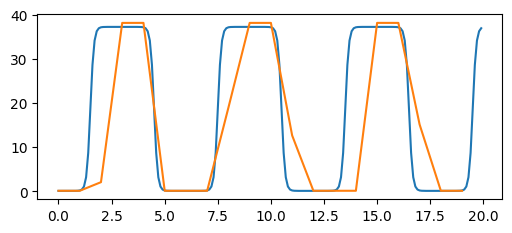

In [5]:
plt.figure(figsize=(6, 2.4))
plt.plot(np.arange(0, 20., 0.1), [step_load(i)*31e-4 for i in np.arange(0, 20, 0.1)])
plt.plot(expdata_AST["I_LOAD_A"].iloc[60003:60023].tolist())

In [6]:
operating_inputs = {'current_density': lambda x: 0.1e4, 'Tfc': 353.15, 
                                    'Pa_des': 1.8e5, 'Pc_des': 1.8e5,
                                    'Phi_a_des': 0.0, 'Phi_c_des': 0.85,
                                    'Sa': 1.2, 'Sc': 2.,
                                    'Imin_aux': 10}

undetermined_physical_parameters = {'epsilon_gdl': 0.6, "epsilon_cl": 0.35,
                                                                        'epsilon_mc': 0.399,'epsilon_c': 0.189, 
                                                                        'e': 4, 'kappa_co': 37.2, 'Re': 2.2e-7, 'tau': 1.01, 
                                                                        'i0_c_ref': 2.16, 'kappa_c': 1.9, 'C_scl': 1e8, 
                                                                        'a_slim': 0.4, 'b_slim': 0.5, 'a_switch': 0.5,
                                                                        "Hcl": 1e-5, "Hgdl": 2.e-4, "OCV": 0.92}

parameters = {**current_parameters, **accessible_physical_parameters,
                          **undetermined_physical_parameters, **computing_parameters}

In [7]:
Kem_in =1e-6 # kg.s-1.Pa-1. It is the exhaust manifold inlet orifice constant.

In [8]:
operating_inputs["current_density"] = lambda x: 0.2e4
operating_inputs["Phi_c_des"] = 0.85
operating_inputs["Sa"] = 1.2
operating_inputs["Sc"] = 2
operating_inputs["Pa_des"] = 1.8e5
operating_inputs["Pc_des"] = 1.8e5
operating_inputs["Tfc"] = 353.15
model = PEMFC(param=parameters, operating_inputs=operating_inputs,
              variable_names=solver_variable_names, flux_names=solver_flux_names)
solution_init = init_x(operating_inputs, parameters)
S = model.jac_sparsity(solution_init)
sol = solve_ivp(model.dxdt, t_span=(0,60), y0=solution_init, method='BDF', max_step=0.1, jac_sparsity=S, atol = 1e-4)

In [9]:
operating_inputs["current_density"] = step_load
S = model.jac_sparsity(solution_init)
sol = solve_ivp(model.dxdt, t_span=(0,60), y0=solution_init, method='BDF', max_step=0.1, jac_sparsity=S, atol = 1e-4)

C:\Users\ykh_w\AppData\Roaming\Python\Python311\site-packages\scipy\integrate\_ivp\common.py:408: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
C:\Users\ykh_w\AppData\Roaming\Python\Python311\site-packages\scipy\integrate\_ivp\common.py:447: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE
C:\Users\ykh_w\AppData\Roaming\Python\Python311\site-packages\scipy\integrate\_ivp\common.py:391: RuntimeWarning: invalid value encountered in multiply
  h_vecs[group] = h * e
C:\Users\ykh_w\AppData\Roaming\Python\Python311\site-packages\scipy\integrate\_ivp\common.py:418: RuntimeWarning: invalid value encountered in multiply
  h_vecs[k] = h_new_all * e


In [10]:
model._recovery(sol)

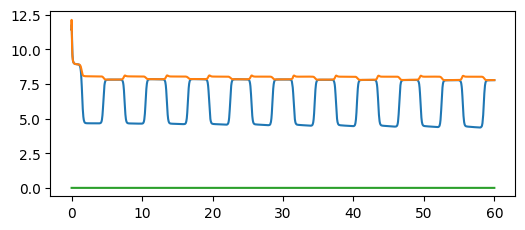

In [11]:
plt.figure(figsize=(6,2.4))
plt.plot(model.variables["t"], model.variables["C_O2_ccl"])
plt.plot(model.variables["t"], model.variables["C_O2_cgc"])
plt.plot(model.variables["t"], model.variables["C_O2_mem_1"])

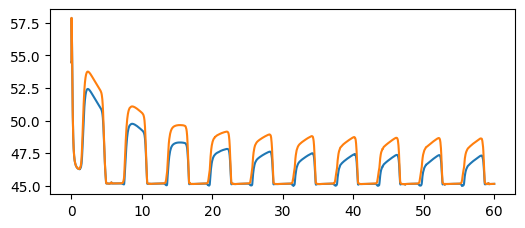

In [12]:
plt.figure(figsize=(6,2.4))
plt.plot(model.variables["t"], model.variables["C_H2_acl"])
plt.plot(model.variables["t"], model.variables["C_H2_agc"])

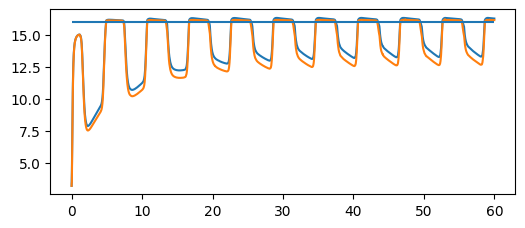

In [13]:
plt.figure(figsize=(6,2.4))
plt.plot(model.variables["t"], model.variables["C_v_acl"])
plt.plot(model.variables["t"], model.variables["C_v_agc"])
plt.hlines(C_v_sat(353),0, model.variables["t"][-1])

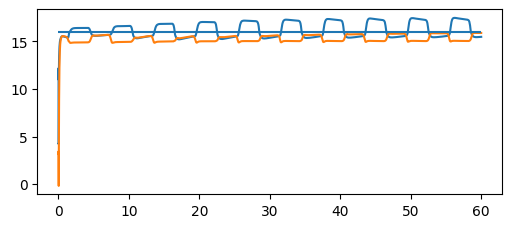

In [14]:
plt.figure(figsize=(6,2.4))
plt.plot(model.variables["t"], model.variables["C_v_ccl"])
plt.plot(model.variables["t"], model.variables["C_v_cgc"])
plt.hlines(C_v_sat(353),0, model.variables["t"][-1])

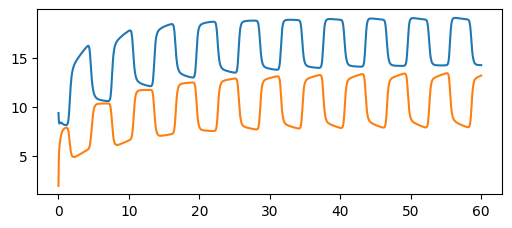

In [15]:
plt.figure(figsize=(6,2.4))
plt.plot(model.variables["t"], model.variables["lambda_ccl"])
plt.plot(model.variables["t"], model.variables["lambda_acl"])

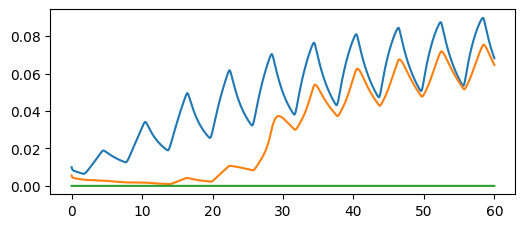

In [16]:
plt.figure(figsize=(6,2.4))
plt.plot(model.variables["t"], model.variables["s_cgdl_1"])
plt.plot(model.variables["t"], model.variables["s_cgdl_5"])
plt.plot(model.variables["t"], model.variables["s_cgdl_10"])

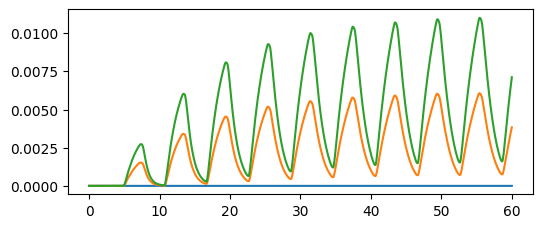

In [17]:
plt.figure(figsize=(6,2.4))
plt.plot(model.variables["t"], model.variables["s_agdl_1"])
plt.plot(model.variables["t"], model.variables["s_agdl_5"])
plt.plot(model.variables["t"], model.variables["s_agdl_10"])

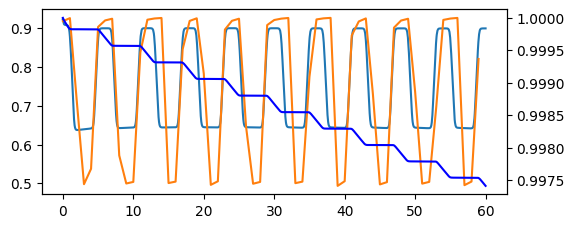

In [18]:
fig, ax =  plt.subplots(figsize=(6,2.4))
ax.plot(model.variables["t"], model.echem_traj["Ucell"])
ax.plot(expdata_AST["VFC_10V"].iloc[60003:60063].to_numpy()/22)
ax.twinx().plot(model.variables["t"], model.echem_traj["S_N"], color = "b")